##### y = b0 + b1x1 + b2x1^2 + b3x1^3 ...

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
dataset = pd.read_csv('data/icecream.csv')

In [6]:
dataset.head()

,Temp,icecream
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


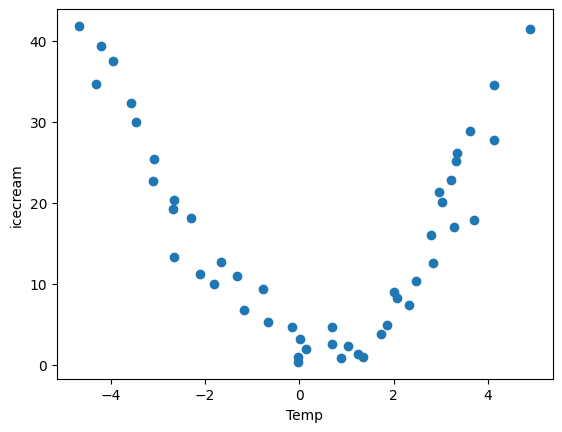

In [10]:
plt.scatter(dataset["Temp"], dataset["icecream"])
plt.xlabel("Temp")
plt.ylabel("icecream")
plt.show()

In [8]:
dataset.corr()

,Temp,icecream
Temp,1.000000,-0.175184
icecream,-0.175184,1.000000


In [109]:
x = dataset[["Temp"]]
y = dataset["icecream"]

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [110]:
pf = PolynomialFeatures(degree = 2)
pf.fit(x)
x = pf.transform(x)

In [111]:
x.shape

(49, 3)

In [112]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [113]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [114]:
lr.score(x_test, y_test)

0.8697223942969939

In [115]:
lr.coef_

array([ 0.        , -0.65035708,  1.85398314])

In [116]:
lr.intercept_

np.float64(2.9566940409422866)

In [117]:
pred = lr.predict(x)

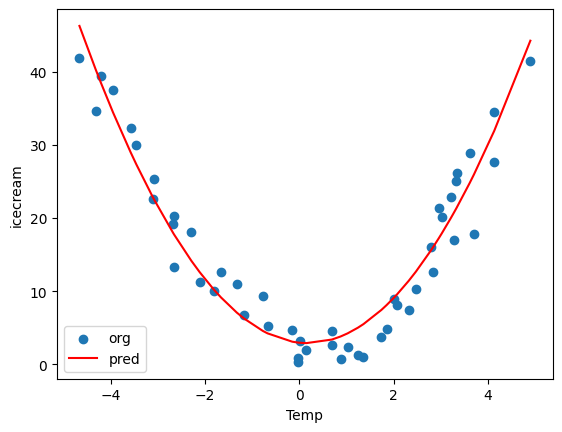

In [118]:
plt.scatter(dataset["Temp"], dataset["icecream"])
plt.plot(dataset["Temp"], pred, color="red")
plt.xlabel("Temp")
plt.ylabel("icecream")
plt.legend(["org", "pred"])
plt.show()